In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cs-training.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(150000, 12)
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100)

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


## There it is. The class imbalance problem.
### 93.3% didn't default — only 6.7% defaulted.
### This is a serious problem.
If we train a model on this directly — it will learn to always predict 0 (no default) and still get 93% accuracy. But it will completely miss all actual defaulters.
That's useless for a bank. Missing a defaulter is exactly the costly mistake they're trying to avoid.
## This is called the Class Imbalance Problem.
We'll fix it using a technique called SMOTE — Synthetic Minority Oversampling Technique.
It creates synthetic examples of the minority class (defaulters) to balance the dataset.
But first — let's complete EDA.
### Step 2 — Check missing values:

In [4]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate            

NumberOfDependents — only 2.6% missing. Dropping entire column wastes useful data. Bad idea.
MonthlyIncome — 19.8% missing. But income is crucial for predicting default. Dropping column loses important signal. Bad idea.

So we fill both. 

Most people earn moderate income
But some people earn extremely high income — billionaires, executives
Those extreme high values pull the mean upward

That sounds like — skewed or symmetric?
Skewed. Right skewed just like Age in Titanic.
So for MonthlyIncome → Median is safer.
For NumberOfDependents — most people have 0-3 dependents, few have many. Also skewed → Median.

In [5]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Verify
print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_404\1978127798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_404\1978127798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

print(X.shape)
print(y.shape)

(150000, 10)
(150000,)


In [8]:
import sys
!{sys.executable} -m pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.23.5

   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-1.23.5:
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
      Successfully uninstalled numpy-1.23.5
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split first before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().tolist())
print("After SMOTE:", y_train_smote.value_counts().tolist())

Before SMOTE: [111930, 8070]
After SMOTE: [111930, 111930]


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}")

              precision    recall  f1-score   support

           0       0.96      0.92      0.94     28044
           1       0.29      0.46      0.36      1956

    accuracy                           0.89     30000
   macro avg       0.63      0.69      0.65     30000
weighted avg       0.92      0.89      0.90     30000

ROC-AUC Score: 0.8228


In [10]:
import pickle

with open('credit_default_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully")

Model saved successfully


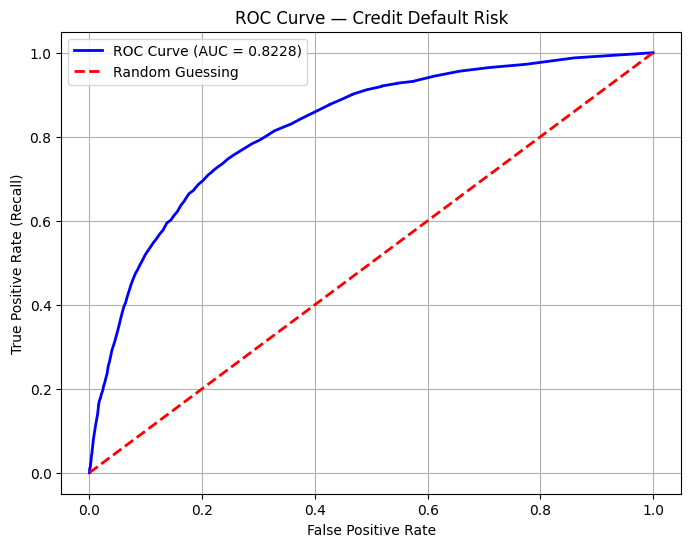

In [11]:
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Random Guessing')
plt.title('ROC Curve — Credit Default Risk')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gfhd pgp
f[osd /]